In [5]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from category_encoders import OneHotEncoder
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.preprocessing import FunctionTransformer
import re
import optuna
import time
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pickle
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [6]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

In [7]:
cleaned_df = pd.read_csv("/Users/oronje/Desktop/Data_Sprint_2026/data/processed/cleaned_data.csv")

#  Machine learning

###  Creating the Feature Matrix and Target Vector

In [8]:
target = "financial_status"
Features = [col for col in cleaned_df.columns if col not in [target]]
X = cleaned_df[Features]
y = cleaned_df[target]
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Feature columns: {X.columns.tolist()}")

Features shape: (20871, 27)
Target shape: (20871,)
Feature columns: ['county', 'location_type', 'Sex', 'Age', 'household_size', 'education_level', 'marital_status', 'monthly_income', 'Savings_formal', 'Savings_informal', 'Loan_formal', 'Loan_informal', 'defaulted', 'formal_service_use', 'mobile_money_access', 'barriers_mobile_money', 'mobile_ownership_1', 'experienced_shock', 'nfhi_11', 'nfhi_12', 'nfhi_13', 'accessto_13k_1month', 'not_difficult', 'fl_score', 'prodsum1', 'barriers_bank', 'has_disability']


In [9]:
y.value_counts()

financial_status
Worsened           10981
Stayed the same     5609
Improved            4281
Name: count, dtype: int64

### Train-test split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Split train further into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=42, stratify= y_train
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 12522 samples
Validation set: 4174 samples
Test set: 4175 samples


## RandomForest Classifier

In [12]:
rf = make_pipeline(
   OneHotEncoder(use_cat_names=True),  
   StandardScaler(with_mean=False),   
   RandomForestClassifier(n_estimators=300,class_weight='balanced',random_state=42, n_jobs=-1)
)
# Training timer
start_train = time.time()
rf.fit(X_train, y_train)
train_time = time.time() - start_train
print(f"⏱ Training time: {train_time:.2f} seconds")

# Prediction timer
start_pred = time.time()
val_pred = rf.predict(X_val)
pred_time = time.time() - start_pred
print(f"⏱ Prediction time: {pred_time:.4f} seconds")

# Classification report
print(classification_report(y_val, val_pred, digits=3))

⏱ Training time: 1.08 seconds
⏱ Prediction time: 0.1092 seconds
                 precision    recall  f1-score   support

       Improved      0.401     0.411     0.406       856
Stayed the same      0.426     0.359     0.390      1122
       Worsened      0.652     0.698     0.674      2196

       accuracy                          0.548      4174
      macro avg      0.493     0.489     0.490      4174
   weighted avg      0.540     0.548     0.543      4174



📋 Random Forest Report 

- The Random Forest model achieves a Weighted F1-score of 0.548, making it the best-performing model overall. 
- It demonstrates strong predictive ability for the majority class (Worsened, F1: 0.674), while performance on the minority classes (“Improved” and “Stayed the same”) remains moderate. 
- This indicates that the model is strongly influenced by the underlying class distribution, performing best where data density is highest. Despite this, it provides the most stable and reliable overall performance among all tested models.

## LightGBM classifier

In [13]:
lgbm = make_pipeline(
   OneHotEncoder(use_cat_names=True),   
   LGBMClassifier(n_estimators=500, learning_rate=0.05, class_weight='balanced', random_state=42, n_jobs=-1)
)
# Training time
start_train = time.time()
lgbm.fit(X_train, y_train)
train_time = time.time() - start_train
print(f"⏱ Training time: {train_time:.2f} seconds")

# Prediction timer
start_pred = time.time()
val_pred = lgbm.predict(X_val)
pred_time = time.time() - start_pred
print(f"⏱ Prediction time: {pred_time:.4f} seconds")

# Classification report
print(classification_report(y_val, val_pred, digits=3))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001786 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 408
[LightGBM] [Info] Number of data points in the train set: 12522, number of used features: 123
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
⏱ Training time: 5.95 seconds
⏱ Prediction time: 0.1063 seconds
                 precision    recall  f1-score   support

       Improved      0.369     0.472     0.414       856
Stayed the same      0.393     0.400     0.397      1122
       Worsened      0.672     0.592     0.630      2196

       accuracy                          0.516      4174
      macro avg      0.478     0.488     0.480      41

📋 LightGBM Report 

- The LightGBM model achieves a Weighted F1-score of 0.523, which is lower than both Random Forest and XGBoost. 
- It shows improved balance across classes, with relatively better recall for the minority class (“Improved”, F1: 0.414), suggesting that the model is more sensitive to underrepresented outcomes. 
- However, this improvement comes at the cost of reduced performance on the majority class, leading to a lower overall weighted F1-score. As a result, LightGBM provides better class balance but weaker overall predictive strength.

## XGBoost Classifier

In [14]:
#  Map string labels to integers (0, 1, 2)
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_val_encoded = le.transform(y_val)

# Compute sample weights using the numeric target to address class imbalance
sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train_encoded
)

#  Helper function to strip out [, ], and < from feature names
def clean_feature_names(X):
    if isinstance(X, pd.DataFrame):
        # Replace [, ], and < with an underscore or text equivalent
        new_cols = [re.sub(r'[\[\]<]', '_', str(col)) for col in X.columns]
        X.columns = new_cols
    return X

xgb = make_pipeline(
    OneHotEncoder(use_cat_names=True),
    FunctionTransformer(clean_feature_names, validate=False),
    XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        eval_metric="mlogloss"
    )
)

# 4. Training time
start_train = time.time()
xgb.fit(X_train, y_train_encoded, xgbclassifier__sample_weight=sample_weights)
train_time = time.time() - start_train
print(f"⏱ Training time: {train_time:.2f} seconds")

# 5. Prediction timer
start_pred = time.time()
val_pred = xgb.predict(X_val)  
pred_time = time.time() - start_pred
print(f"⏱ Prediction time: {pred_time:.4f} seconds")

# 6. Classification report
print(classification_report(y_val_encoded, val_pred, target_names=le.classes_, digits=3))

⏱ Training time: 3.03 seconds
⏱ Prediction time: 0.0373 seconds
                 precision    recall  f1-score   support

       Improved      0.375     0.496     0.427       856
Stayed the same      0.418     0.403     0.410      1122
       Worsened      0.682     0.609     0.643      2196

       accuracy                          0.530      4174
      macro avg      0.492     0.503     0.494      4174
   weighted avg      0.548     0.530     0.536      4174



📋 XGBoost Report 

- The XGBoost model achieves a Weighted F1-score of 0.536, placing it between Random Forest and LightGBM in terms of overall performance. 
- It delivers a balanced trade-off between class performance, improving recall for the minority class (“Improved”, F1: 0.427) while maintaining competitive performance on the majority class (“Worsened”, F1: 0.643). 
- Although it does not surpass Random Forest on the primary metric, it demonstrates strong generalization and more balanced behavior across classes compared to a purely majority-driven model.

# Final Model Decision

- Based on the evaluation using the Weighted F1-score (primary metric), the Random Forest model is selected as the final model. 
- It achieves the highest overall performance (Weighted F1 = 0.548) while maintaining stable and consistent results across all classes.
- Although XGBoost and LightGBM provide more balanced class-level behavior, neither model improves upon the primary metric. 
- Therefore, Random Forest offers the best overall trade-off between predictive performance, stability, and computational efficiency, making it the most suitable model for this problem under the defined evaluation criteria.

## Hyperparameter Tuning  for RandomForest

In [15]:
def objective_rf(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 800),
        "max_depth": trial.suggest_int("max_depth", 5, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
        "max_features": trial.suggest_float("max_features", 0.3, 0.9),
        "class_weight": "balanced",
        "random_state": 42,
        "n_jobs": -1
    }



    pipeline = make_pipeline(
        OneHotEncoder(use_cat_names=True),
        StandardScaler(with_mean=False),  
        RandomForestClassifier(**params)
    )

    pipeline.fit(X_train, y_train)

    val_preds = pipeline.predict(X_val)

    return f1_score(y_val, val_preds, average="weighted")


# Run study
study_rf = optuna.create_study(direction="maximize")
study_rf.optimize(objective_rf, n_trials=30)

print("🏆 Best Random Forest Weighted F1-Score:", study_rf.best_value)
print("⚙️ Best Random Forest Params:", study_rf.best_params)

[I 2026-06-16 15:04:38,086] A new study created in memory with name: no-name-3e359dba-b931-486d-9488-dd341f4c381c
[I 2026-06-16 15:04:40,672] Trial 0 finished with value: 0.5114886951273575 and parameters: {'n_estimators': 517, 'max_depth': 15, 'min_samples_split': 4, 'min_samples_leaf': 20, 'max_features': 0.5440221585956758}. Best is trial 0 with value: 0.5114886951273575.
[I 2026-06-16 15:04:44,627] Trial 1 finished with value: 0.5137303596281348 and parameters: {'n_estimators': 789, 'max_depth': 11, 'min_samples_split': 12, 'min_samples_leaf': 14, 'max_features': 0.610650962071294}. Best is trial 1 with value: 0.5137303596281348.
[I 2026-06-16 15:04:47,872] Trial 2 finished with value: 0.5186860253334207 and parameters: {'n_estimators': 463, 'max_depth': 20, 'min_samples_split': 15, 'min_samples_leaf': 11, 'max_features': 0.7499793667618336}. Best is trial 2 with value: 0.5186860253334207.
[I 2026-06-16 15:04:49,455] Trial 3 finished with value: 0.5256231170361568 and parameters: {

🏆 Best Random Forest Weighted F1-Score: 0.5332288563758225
⚙️ Best Random Forest Params: {'n_estimators': 609, 'max_depth': 30, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 0.8582140242822685}


Hyperparameter tuning of the Random Forest model using Optuna resulted in a best Weighted F1-score of 0.533, which is slightly lower than the baseline performance (0.546). Across trials, performance showed limited variation, indicating that changes in model configuration have minimal impact on predictive performance. This suggests that the Random Forest model has reached a performance plateau 

## Final Model Evaluation on Test Data (Random Forest)

In [18]:
final_rf_model = make_pipeline(
   OneHotEncoder(use_cat_names=True), 
   StandardScaler(with_mean=False),    
   RandomForestClassifier(n_estimators=300,class_weight='balanced',random_state=42, n_jobs=-1)
)
# Training timer
start_train = time.time()
final_rf_model.fit(X_train, y_train)
train_time = time.time() - start_train
print(f"⏱ Training time: {train_time:.2f} seconds")

# Prediction timer
start_pred = time.time()
y_pred = final_rf_model.predict(X_test)
pred_time = time.time() - start_pred
print(f"⏱ Prediction time: {pred_time:.4f} seconds")

# Classification report
print("\n 📊 CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred, digits=3))
print("=" * 65)


⏱ Training time: 1.00 seconds
⏱ Prediction time: 0.1083 seconds

 📊 CLASSIFICATION REPORT:
                 precision    recall  f1-score   support

       Improved      0.391     0.410     0.400       856
Stayed the same      0.414     0.332     0.369      1122
       Worsened      0.648     0.701     0.674      2197

       accuracy                          0.543      4175
      macro avg      0.485     0.481     0.481      4175
   weighted avg      0.533     0.543     0.536      4175



In [20]:
# save model
path = '/Users/oronje/Desktop/Data_Sprint_2026/models'
def save_model(model, model_filepath):

    with open(model_filepath, 'wb') as file:

        pickle.dump(model, file)

save_model(final_rf_model,path+'/rf_model.pkl')

📋 Random Forest — Test Performance Summary

- The Random Forest model achieves a Weighted F1-score of 0.536 on the test set with an accuracy of 0.543. 
- It shows strong performance on the majority class (Worsened, F1 = 0.674), but significantly weaker performance on the Stayed the same class (F1 = 0.369). 
- Overall, the model is stable and slightly favors the majority class, leading to reasonable but unbalanced predictive performance across classes.

## Confusion Matrix

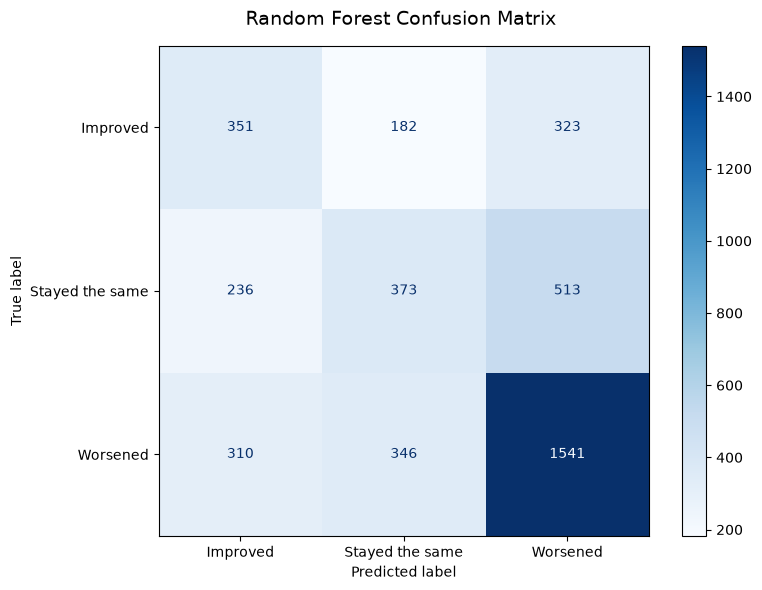

In [17]:
# Calculate and plot the Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=final_rf_model.classes_)

# Create the visual plot
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=final_rf_model.classes_)

# Plot with a nice color map (Blues, Viridis, or Plasma work well)
disp.plot(cmap="Blues", ax=ax, values_format="d") 

plt.title("Random Forest Confusion Matrix ", fontsize=14, pad=15)
plt.grid(False) 
plt.tight_layout()
plt.show()

 📊 Confusion Matrix Interpretation (Random Forest)



### 🟢 Improved

Out of **856** actual “Improved” cases:

* **351** were correctly classified
* **182** were misclassified as “Stayed the same”
* **323** were misclassified as “Worsened”

👉 The model struggles to clearly separate “Improved” from the other classes, particularly confusing it with “Worsened”.

---

### 🟡 Stayed the same

Out of **1,122** actual “Stayed the same” cases:

* **373** were correctly classified
* **236** were predicted as “Improved”
* **513** were predicted as “Worsened”

👉 This is the weakest class performance, with a strong tendency to be misclassified as “Worsened”.

---

### 🔴 Worsened

Out of **2,197** actual “Worsened” cases:

* **1,541** were correctly classified
* **310** were misclassified as “Improved”
* **346** were misclassified as “Stayed the same”

👉 This class is predicted most accurately, indicating the model is strongest at identifying the dominant class.

---

## 📌 Key Insights

* The model performs best on the **“Worsened”** class due to its higher representation in the data.
* Most misclassifications occur between **“Stayed the same” and “Worsened”**, indicating overlap in feature patterns.
* “Improved” is moderately captured but still frequently confused with both other classes.

